In [411]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torch.optim as optim
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import random_split
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [412]:
BLUE = "\033[94m"
GREEN = "\033[92m"
MAGENTA = "\033[95m"
CYAN = "\033[96m"
YELLOW = "\033[93m"
RESET = "\033[0m"

In [413]:
learning_rate = 0.0007
patience = 5
epochs = 10
batch_size = 32  # 32 de dene!

In [414]:
cifar_transform = transforms.Compose([transforms.Grayscale(num_output_channels=1),
                                      transforms.Resize((28, 28)),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.RandomRotation(10),
                                      transforms.RandomAffine(0, translate=(0.1, 0.1)), #silinebilir
                                      transforms.ToTensor(),
                                      transforms.Normalize((0.5,), (0.5,))
                                      ])

mnist_transform = transforms.Compose([transforms.ToTensor(),
                                      transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
                                      transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3)),#silinebilir
                                      transforms.Normalize((0.5,), (0.5,))
                                      ])

In [415]:
class TaggedDataset(Dataset):
    def __init__(self, dataset, tag):
        self.dataset = dataset
        self.tag = tag

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return img, label, self.tag  # tag: 0 for MNIST, 1 for CIFAR

MNIST Tag is 0
CIFAR10 Tag is 1

In [416]:
mnist = TaggedDataset(datasets.MNIST(root='./data', train=True, download=True,
                            transform=mnist_transform), tag=0)

cifar = TaggedDataset(datasets.CIFAR10(root='./data', train=True, download=True,
                              transform=cifar_transform), tag=1)

In [417]:
combined_dataset = ConcatDataset([mnist, cifar])

aşağıda random split yapmak mı daha iyi olur? yoksa acaba hepsi için ayrı mnist/cifar10 data seti mi oluşturmalıydık?

"mnist_train = torchvision.datasets.MNIST(root='./data', train=True, 
                                           download=True, transform=mnist_transform)
    mnist_test = torchvision.datasets.MNIST(root='./data', train=False, 
                                          download=True, transform=mnist_transform)"

bunun gibi

bence random_split iyi gibi ama soralım

In [418]:
train_ratio = 0.7
val_raito = 0.15
test_ratio = 0.15

dataset_len = len(combined_dataset)
train_len = int(train_ratio * dataset_len)
val_len = int(val_raito * dataset_len)
test_len = dataset_len - train_len - val_len

dataset_train, dataset_val, dataset_test = random_split(combined_dataset, [train_len, val_len, test_len])

In [419]:
train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)
#test_loader batch_size=1 ???? ne faydası oluyor sor

In [ ]:

class MixedCNN(nn.Module):
    def __init__(self):
        super(MixedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(256 * 1 * 1, 512) 
        self.fc2 = nn.Linear(512, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        
        x = x.view(-1, 256 * 1 * 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [ ]:
model = MixedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.1)#model ilerlemesi durunca lr'yi azaltıyor

running_losslist = []
valid_losslist = []

valid_loss_min = np.inf
patience_counter = 0


for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    valid_loss = 0.0
    train_acc = 0.0
    valid_acc = 0.0
    
    correct = 0
    total = 0

    for inputs, labels, tag in tqdm(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_acc += (predicted == labels).sum().item()

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    model.eval()
    with torch.no_grad():
        for data, target, tag in tqdm(val_loader):
            optimizer.zero_grad()
            data, target = data.to(device), target.to(device)
            output = model(data)

            loss_val = criterion(output, target)
            valid_loss += loss_val.item() * data.size(0)
            _, predicted = torch.max(output.data, 1)
            valid_acc += (predicted == target).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    train_loss = running_loss / len(train_loader.dataset)
    valid_loss = valid_loss / len(val_loader.dataset)

    train_acc = train_acc / len(train_loader.dataset)
    valid_acc = valid_acc / len(val_loader.dataset)

    scheduler.step(valid_loss)#genel olarak validation için yapılıyormuş


    print(f'{CYAN}Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {valid_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {valid_acc:.4f}{RESET}')
    running_losslist.append(running_loss)
    valid_losslist.append(valid_loss)


    if valid_loss <= valid_loss_min:
        valid_loss_min = valid_loss
        patience_counter = 0
    elif patience_counter < patience:
        patience_counter += 1
    else:
        model.eval()
        print(f"{YELLOW}Early stopping{RESET}")
        break

100%|██████████| 516/516 [00:06<00:00, 83.99it/s]


Epoch [1/10], Train Loss: 0.9500, Val Loss: 0.7530, Train Acc: 0.6638, Val Acc: 0.7341


100%|██████████| 516/516 [00:06<00:00, 82.17it/s]


Epoch [2/10], Train Loss: 0.6966, Val Loss: 0.6369, Train Acc: 0.7591, Val Acc: 0.7782


100%|██████████| 516/516 [00:06<00:00, 82.29it/s]


...

Epoch [8/10], Train Loss: 0.4719, Val Loss: 0.4671, Train Acc: 0.8391, Val Acc: 0.8389


100%|██████████| 516/516 [00:06<00:00, 81.61it/s]


Epoch [9/10], Train Loss: 0.4527, Val Loss: 0.4579, Train Acc: 0.8440, Val Acc: 0.8421


100%|██████████| 516/516 [00:06<00:00, 80.68it/s]

Epoch [10/10], Train Loss: 0.4409, Val Loss: 0.4565, Train Acc: 0.8503, Val Acc: 0.8422


batch size=128 için train acc:%70, val acc: %77 (zik zak çizmedi)(lr=0.001)(CNN)

batch size=64 için train acc:%72, val acc: %77 (zik zak çizmedi)(lr=0.001)(CNN)

batch size=32 için train acc:%74, val acc: %79 (zik zak çizmedi)(lr=0.001)(CNN)

batch size=24 için train acc:%74, val acc: %79 (zik zak çizmedi)(lr=0.0007)(CNN)

batch size=16 için train acc:%74, val acc: %79 (zik zak çizmedi)(lr=0.0007)(CNN)

batch size=24 için train acc:%83, val acc: %84 (zik zak çizmedi)(lr=0.0007)(CNN with 3 conv layer)

batch size=128 için train acc:%83, val acc: %84 (zik zak çizmedi)(lr=0.001)(CNN with 3 conv layer)

batch size=32 için train acc:%85, val acc: %84 (zik zak çizmedi)(lr=0.001)(CNN with 4 conv layer)

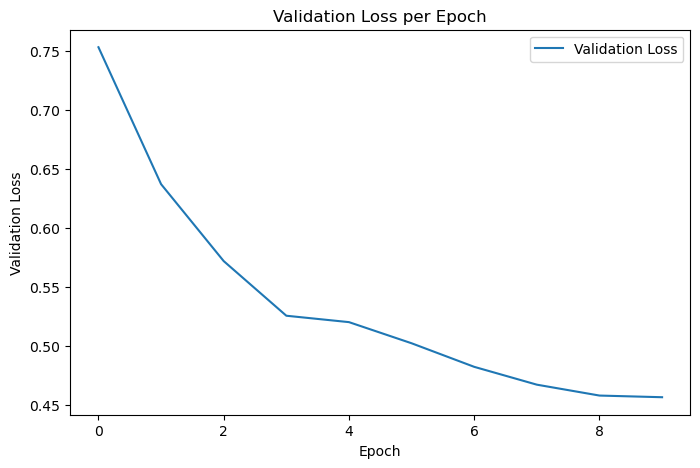

In [422]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(valid_losslist, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss per Epoch')
plt.legend()
plt.show()